### Thorium oligomerisation project - Lithium

### H-bond analysis

The following code runs a standardised MD analysis of hydrogen bonds, structural and solvent analyses. It will display plots in the notebook and save images to the directory your simulations are stored.

In [1]:
! pip list | grep MDAnalysis

MDAnalysis                2.9.0


In [2]:
import logging

import pandas as pd

pd.set_option("display.max_columns", 500)
_fmt = "%(asctime)s - %(levelname)s: %(message)s"
logging.basicConfig(level=logging.INFO, format=_fmt)

In [3]:
# from analyses.hbond_analysis import plot_hbond_analysis
# from analyses.utils.mda_utils import draw_mols_with_mda_atom_nums

# from analyses.HydrogenBondNetwork import DirectHydrogenBonding as DirectHydrogenBonding
# from analyses.HydrogenBondNetwork import WaterMediatedHydrogenBonding as WaterMediatedHydrogenBonding

### Water bridge analysis.

In [4]:
simulation_path = '/media/corey/hzdrBackup/01_HZDR/_adhoc/04_Julia/03_ThNPAnions/02_Th_Li/results/'
HETA = 'Th'
HETB = 'NO3'
HETC = 'Li'

In [5]:
import numpy as np
import MDAnalysis as mda
import matplotlib.pyplot as plt
# import networkx as nx
# from MDAnalysis.analysis.distances import distance_array
# from MDAnalysis.analysis.rdf import InterRDF
# import scipy.stats as stats
# from MDAnalysis.lib.correlations import autocorrelation,correct_intermittency
# import MDAnalysis.analysis.align
# import MDAnalysis.analysis.density
# import tqdm
# from  MDAnalysis.analysis.hydrogenbonds.hbond_analysis import HydrogenBondAnalysis as HBA
# import pandas as pd
# import seaborn as sns

2025-09-03 19:20:56,359 - WARNING: netCDF4 is not available. Writing AMBER ncdf files will be slow.
2025-09-03 19:20:56,410 - INFO: Enabling RDKit 2025.03.5 jupyter extensions


In [6]:
topology = f'{simulation_path}/step5_1.psf' #MDA structure file
u = mda.Universe(topology)

/home/corey/miniconda3/envs/docking_md/lib/python3.11/site-packages/MDAnalysis/core/universe.py:150: UserWarning: No coordinate reader found for /media/corey/hzdrBackup/01_HZDR/_adhoc/04_Julia/03_ThNPAnions/02_Th_Li/results//step5_1.psf. Skipping this file.
  warnings.warn('No coordinate reader found for {}. Skipping '
2025-09-03 19:20:56,643 - INFO: The attribute(s) masses, types have already been read from the topology file. The guesser will only guess empty values for this attribute, if any exists. To overwrite it by completely guessed values, you can pass the attribute to the force_guess parameter instead of the to_guess one
2025-09-03 19:20:56,644 - INFO: There is no empty types values. Guesser did not guess any new values for types attribute
2025-09-03 19:20:56,644 - INFO: There is no empty masses values. Guesser did not guess any new values for masses attribute


In [7]:
# from MDAnalysis.coordinates.XTC import XTCWriter

# Create combined traj - commented out for now

# u = mda.Universe(topology, f'{simulation_path}/step5_1.dcd')

# with mda.Writer(f'{simulation_path}/combined_trajectory.dcd', u.atoms.n_atoms) as writer:
#     # Write frames from the first trajectory
#     for ts in u.trajectory:
#         writer.write(u)  # Write each frame to the output file
    
#     # Loop through the remaining trajectory files and append frames
#     for i in range(1,201):
#         u.load_new(f'{simulation_path}/step5_{i}.dcd')  # Load next trajectory
#         for ts in u.trajectory:
#             writer.write(u)  # Write each frame to the output file

In [8]:
u = mda.Universe(topology, f'{simulation_path}/combined_trajectory.dcd')

/home/corey/miniconda3/envs/docking_md/lib/python3.11/site-packages/MDAnalysis/coordinates/DCD.py:165: DeprecationWarning: DCDReader currently makes independent timesteps by copying self.ts while other readers update self.ts inplace. This behavior will be changed in 3.0 to be the same as other readers. Read more at https://github.com/MDAnalysis/mdanalysis/issues/3889 to learn if this change in behavior might affect you.
  warnings.warn("DCDReader currently makes independent timesteps"
2025-09-03 19:20:57,348 - INFO: The attribute(s) masses, types have already been read from the topology file. The guesser will only guess empty values for this attribute, if any exists. To overwrite it by completely guessed values, you can pass the attribute to the force_guess parameter instead of the to_guess one
2025-09-03 19:20:57,349 - INFO: There is no empty types values. Guesser did not guess any new values for types attribute
2025-09-03 19:20:57,349 - INFO: There is no empty masses values. Guesser 

In [9]:
from MDAnalysis.analysis.distances import distance_array
import numpy as np
import networkx as nx
import tqdm

class GeometricHydrogenBonding:
    def __init__(self,
                 universe,
                 donor_sel: str,
                 hydrogen_sel: str,
                 acceptor_sel: str,
                 d_a_cutoff: float = 3.2,
                 d_h_a_angle_cutoff: float = 120.0,
                 start: int = 0,
                 stop: int = -1,
                 step: int = 1):
        
        self.u = universe
        self.donor_sel = donor_sel
        self.hydrogen_sel = hydrogen_sel
        self.acceptor_sel = acceptor_sel
        self.d_a_cutoff = d_a_cutoff
        self.d_h_a_angle_cutoff = d_h_a_angle_cutoff
        self.start = start
        self.stop = stop
        self.step = step

        self._calculate_hbonds()

    def _calculate_hbonds(self):
        u = self.u
        donors = u.select_atoms(self.donor_sel)
        hydrogens = u.select_atoms(self.hydrogen_sel)
        acceptors = u.select_atoms(self.acceptor_sel)

        donor_hydrogen_pairs = []

        # Get donor-hydrogen pairs: H bonded to D (e.g., O-H)
        for d in donors:
            bonded_h = [h for h in hydrogens if h.bonds and d in h.bonded_atoms]
            for h in bonded_h:
                donor_hydrogen_pairs.append((d.index, h.index))

        self.paths = []

        for ts in tqdm.tqdm(u.trajectory[self.start:self.stop:self.step]):
            da_pairs = []
            for d_idx, h_idx in donor_hydrogen_pairs:
                d = u.atoms[d_idx]
                h = u.atoms[h_idx]

                d_pos = d.position
                h_pos = h.position

                # Compute distance from H to all acceptors
                a_positions = acceptors.positions
                d_to_a = distance_array(d_pos[np.newaxis, :], a_positions)[0]

                # Only consider acceptors within cutoff
                for a_idx, dist in enumerate(d_to_a):
                    if dist <= self.d_a_cutoff:
                        a = acceptors[a_idx]
                        a_pos = a.position

                        # Compute angle D-H-A
                        vec_dh = h_pos - d_pos
                        vec_ha = a_pos - h_pos

                        cosine_angle = np.dot(vec_dh, vec_ha) / (np.linalg.norm(vec_dh) * np.linalg.norm(vec_ha))
                        angle = np.degrees(np.arccos(np.clip(cosine_angle, -1.0, 1.0)))

                        if angle >= self.d_h_a_angle_cutoff:
                            donor_str = f"{d.resname}{d.resid}:{d.name}"
                            acceptor_str = f"{a.resname}{a.resid}:{a.name}"
                            self.paths.append([[donor_str, acceptor_str], ts.frame])

        self.no_frames = len(u.trajectory[self.start:self.stop:self.step])


In [10]:
print(u.segments.segids)

['CLA' 'HETA' 'HETB' 'HETC' 'SOD' 'SOLV']


In [11]:
print("Water atom names:", np.unique(u.select_atoms("segid SOLV").names))
print(f"{HETB} atom names:", np.unique(u.select_atoms("segid HETB").names))

Water atom names: ['H1' 'H2' 'OH2']
NO3 atom names: ['N1' 'O1' 'O2' 'O3']


In [12]:
print("Donors:", u.select_atoms("segid SOLV and name OH2"))
print("Hydrogens:", u.select_atoms("segid SOLV and name H1 H2"))
print("Acceptors:", u.select_atoms("(segid HETB and name O1 O2 O3) or (segid SOLV and name OH2)"))


Donors: <AtomGroup [<Atom 45: OH2 of type 3 of resname TIP3, resid 1 and segid SOLV>, <Atom 48: OH2 of type 3 of resname TIP3, resid 2 and segid SOLV>, <Atom 51: OH2 of type 3 of resname TIP3, resid 3 and segid SOLV>, ..., <Atom 3864: OH2 of type 3 of resname TIP3, resid 1274 and segid SOLV>, <Atom 3867: OH2 of type 3 of resname TIP3, resid 1275 and segid SOLV>, <Atom 3870: OH2 of type 3 of resname TIP3, resid 1276 and segid SOLV>]>
Hydrogens: <AtomGroup [<Atom 46: H1 of type 1 of resname TIP3, resid 1 and segid SOLV>, <Atom 47: H2 of type 1 of resname TIP3, resid 1 and segid SOLV>, <Atom 49: H1 of type 1 of resname TIP3, resid 2 and segid SOLV>, ..., <Atom 3869: H2 of type 1 of resname TIP3, resid 1275 and segid SOLV>, <Atom 3871: H1 of type 1 of resname TIP3, resid 1276 and segid SOLV>, <Atom 3872: H2 of type 1 of resname TIP3, resid 1276 and segid SOLV>]>
Acceptors: <AtomGroup [<Atom 4: O1 of type 364 of resname NO31, resid 3 and segid HETB>, <Atom 5: O2 of type 364 of resname NO31,

In [13]:
print(u)
print("Number of atoms:", len(u.atoms))
print("Number of residues:", len(u.residues))
print("Number of segments:", len(u.segments))
print("Number of frames in trajectory:", len(u.trajectory))

<Universe with 3880 atoms>
Number of atoms: 3880
Number of residues: 1298
Number of segments: 6
Number of frames in trajectory: 19902


In [14]:
for ts in u.trajectory:
    print(f"Frame {ts.frame} — Time: {ts.time:.2f} ps")
    break  # just test one frame

Frame 0 — Time: 0.00 ps


In [15]:
stride = 100 # keep every 100th frame

In [16]:
from MDAnalysis.analysis.hydrogenbonds.hbond_analysis import HydrogenBondAnalysis as HBA

ghb = HBA(
    universe=u,
    donors_sel="(segid HETA or segid HETB or segid SOLV) and name O1 O2 O3 OH2",
    hydrogens_sel="segid SOLV and name H1 H2",
    acceptors_sel="segid HETA or segid HETB or segid SOLV",
    d_a_cutoff=3.2,
    d_h_a_angle_cutoff=120.0
)

ghb.run(start=0, stop=20000, step=stride)  # One call — whole trajectory
print("H-bond count by frame:", ghb.count_by_time)
print("Total H-bonds found:", ghb.hbonds.shape[0])
print("Example H-bonds:\n", ghb.hbonds[:5])

2025-09-03 19:21:02,073 - INFO: Choosing frames to analyze
2025-09-03 19:21:02,073 - INFO: Starting preparation
2025-09-03 19:21:09,293 - INFO: Finishing up


H-bond count by frame: <bound method HydrogenBondAnalysis.count_by_time of <MDAnalysis.analysis.hydrogenbonds.hbond_analysis.HydrogenBondAnalysis object at 0x71502719f850>>
Total H-bonds found: 789477
Example H-bonds:
 [[  0.          44.          46.         225.           3.09277399
  125.32893583]
 [  0.          44.          46.         224.           2.98078913
  145.20330338]
 [  0.          44.          45.         305.           2.9556748
  164.53891355]
 [  0.          44.          45.          54.           3.11689857
  142.33501307]
 [  0.          47.          49.          99.           2.98143187
  140.82453584]]


/home/corey/miniconda3/envs/docking_md/lib/python3.11/site-packages/MDAnalysis/analysis/hydrogenbonds/hbond_analysis.py:809: DeprecationWarning: The `hbonds` attribute was deprecated in MDAnalysis 2.0.0 and will be removed in MDAnalysis 3.0.0. Please use `results.hbonds` instead.
  warnings.warn(wmsg, DeprecationWarning)


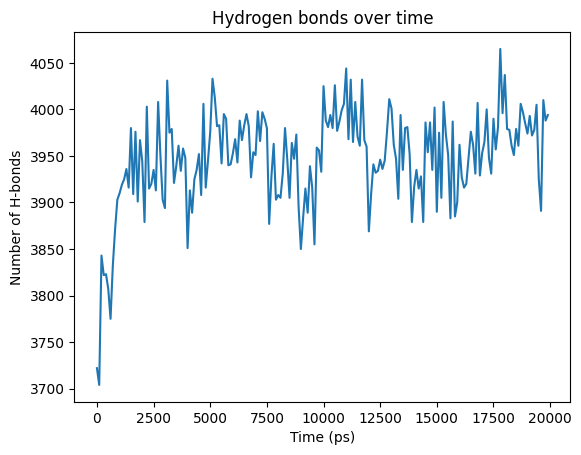

In [ ]:
# Sanity check - plot all h-bonds in the system

hbonds_per_frame = ghb.count_by_time()
times = ghb.times  # time (ps) corresponding to each frame

plt.plot(times, hbonds_per_frame)
plt.xlabel('Time (ps)')
plt.ylabel('Number of H-bonds')
plt.title('Hydrogen bonds over time')
plt.show()

In [18]:
print(f"Atoms in {HETA} segment:", np.unique(u.select_atoms("segid HETA").names))
print(f"Atoms in {HETB} segment:", np.unique(u.select_atoms("segid HETB").names))

Atoms in Th segment: ['TH3P']
Atoms in NO3 segment: ['N1' 'O1' 'O2' 'O3']


In [19]:
hbond_cutoff = 3.0  # H-bond Angstrom cutoff
water_bridge_cutoff = 4.0
first_sphere_cutoff = 5.0

# --- H-bond data ---
donor_indices = ghb.hbonds[:, 1].astype(int)
acceptor_indices = ghb.hbonds[:, 3].astype(int)

donor_segids = u.atoms[donor_indices].segids
acceptor_segids = u.atoms[acceptor_indices].segids

def create_bidirectional_mask(segid1, segid2):
    return ((donor_segids == segid1) & (acceptor_segids == segid2)) | \
           ((donor_segids == segid2) & (acceptor_segids == segid1))

mask_heta_hetb = create_bidirectional_mask("HETA", "HETB")
mask_heta_solv = create_bidirectional_mask("HETA", "SOLV")
mask_hetb_solv = create_bidirectional_mask("HETB", "SOLV")

# Create a mapping from real frame numbers to timepoint indices
frame_to_index = {frame: idx for idx, frame in enumerate(np.unique(ghb.hbonds[:, 0].astype(int)))}

# Get mapped indices for each H-bond
def remap_and_bincount(mask):
    frame_indices = ghb.hbonds[mask, 0].astype(int)
    mapped_indices = np.array([frame_to_index[int(f)] for f in frame_indices]).astype(int)
    return np.bincount(mapped_indices, minlength=len(ghb.times))

# Apply to each segment pair
counts_heta_hetb = remap_and_bincount(mask_heta_hetb)
counts_heta_solv = remap_and_bincount(mask_heta_solv)
counts_hetb_solv = remap_and_bincount(mask_hetb_solv)

# --- Coordination bonds ---

metal = u.select_atoms("segid HETA")

coord_atoms_hetb = u.select_atoms("segid HETB and name O1 O2 O3 N1")
coord_atoms_solv = u.select_atoms("segid SOLV and name OH2")

coord_counts_hetb = []
coord_counts_solv = []
times_coord = []
water_mediated_heta = []
water_mediated_hetb = []

# Use same stride as ghb
for ts in u.trajectory[::stride]:  # <-- Step of 100
    distances_hetb = np.linalg.norm(metal.positions[:, np.newaxis, :] - coord_atoms_hetb.positions[np.newaxis, :, :], axis=2)
    count_hetb = np.sum(np.any(distances_hetb < hbond_cutoff, axis=0))
    
    distances_solv = np.linalg.norm(metal.positions[:, np.newaxis, :] - coord_atoms_solv.positions[np.newaxis, :, :], axis=2)
    count_solv = np.sum(np.any(distances_solv < hbond_cutoff, axis=0))
    
    coord_counts_hetb.append(count_hetb)
    coord_counts_solv.append(count_solv)
    times_coord.append(ts.time)

    # Water-mediated between Th and NO3

    # Distances from HETA to all SOLV waters
    d_heta_solv = np.linalg.norm(metal.positions[:, np.newaxis, :] - coord_atoms_solv.positions[np.newaxis, :, :], axis=2)
    close_to_heta = np.any(d_heta_solv < water_bridge_cutoff, axis=0)

    # Distances from HETB to all SOLV waters
    d_hetb_solv = np.linalg.norm(coord_atoms_hetb.positions[:, np.newaxis, :] - coord_atoms_solv.positions[np.newaxis, :, :], axis=2)
    close_to_hetb = np.any(d_hetb_solv < water_bridge_cutoff, axis=0)

    # Bridging SOLV atoms
    bridge = close_to_heta & close_to_hetb

    # Count how many SOLV atoms bridge
    water_mediated_heta.append(np.sum(bridge))  # or just count nonzero
    water_mediated_hetb.append(np.sum(bridge))  # same, shared bridge count

# Water-water interactions within 5A of Th

heta_atoms = u.select_atoms("segid HETA")
water_atoms = u.select_atoms("segid SOLV and name OH2")

# Store water–water h-bonds near HETA
water_water_near_heta = np.zeros(len(ghb.times), dtype=int)

# Frame time index mapping as before
frame_to_index = {int(round(t)): i for i, t in enumerate(ghb.times)}

for i, hbond in enumerate(ghb.hbonds):
    frame = int(hbond[0])
    donor_idx = int(hbond[1])
    acceptor_idx = int(hbond[3])

    donor = u.atoms[donor_idx]
    acceptor = u.atoms[acceptor_idx]

    if donor.segid == "SOLV" and acceptor.segid == "SOLV":
        # Check if either donor or acceptor is near HETA
        d_donor = np.min(np.linalg.norm(heta_atoms.positions - donor.position, axis=1))
        d_acceptor = np.min(np.linalg.norm(heta_atoms.positions - acceptor.position, axis=1))

        if d_donor < first_sphere_cutoff or d_acceptor < first_sphere_cutoff:
            frame_idx = frame_to_index.get(frame)
            if frame_idx is not None:
                water_water_near_heta[frame_idx] += 1


Non-normalised plots.

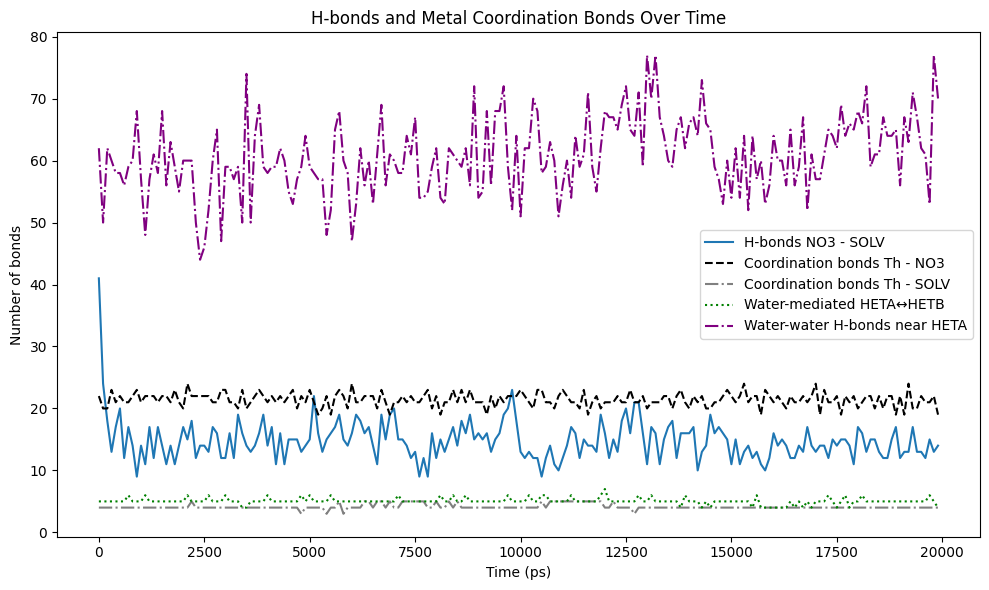

In [20]:
# --- Plotting all together ---
plt.figure(figsize=(10,6))

plt.plot(ghb.times, counts_hetb_solv, label=f"H-bonds {HETB} - SOLV")

plt.plot(times_coord, coord_counts_hetb, label=f"Coordination bonds {HETA} - {HETB}", linestyle='--', color='black')
plt.plot(times_coord, coord_counts_solv, label=f"Coordination bonds {HETA} - SOLV", linestyle='-.', color='gray')

# New plots
plt.plot(times_coord, water_mediated_heta, label="Water-mediated HETA↔HETB", linestyle=':', color='green')
plt.plot(ghb.times, water_water_near_heta, label="Water-water H-bonds near HETA", linestyle='-.', color='purple')


plt.xlabel("Time (ps)")
plt.ylabel("Number of bonds")
plt.title("H-bonds and Metal Coordination Bonds Over Time")
plt.legend()
plt.tight_layout()
plt.show()

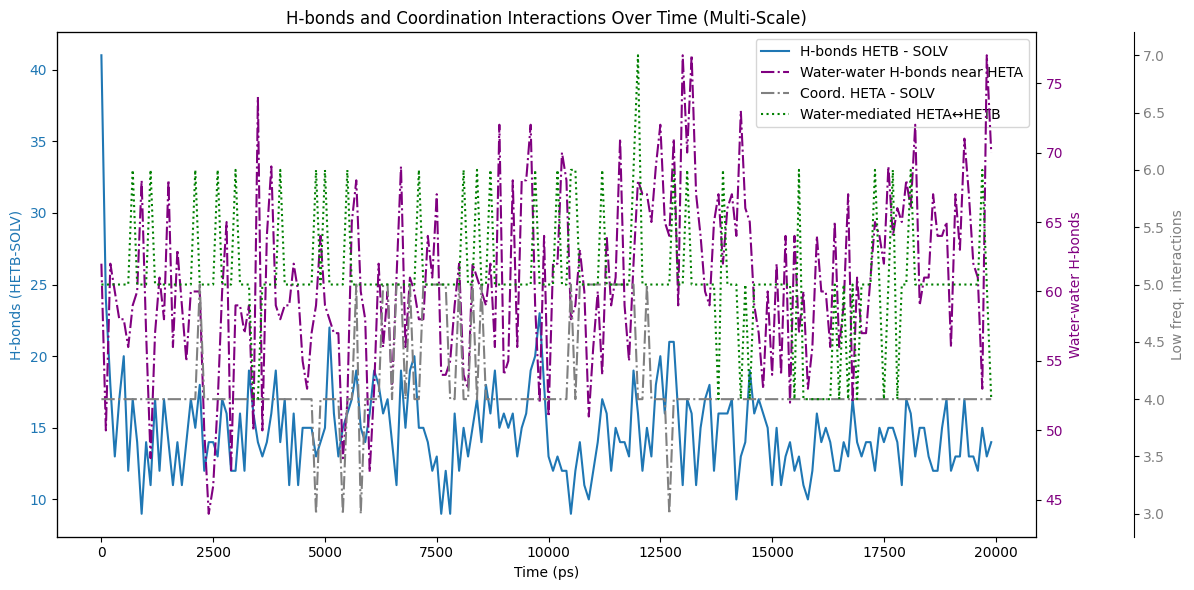

In [21]:
# --- Plotting all together ---
fig, ax1 = plt.subplots(figsize=(12, 6))

# --- Axis 1: Medium-scale data ---
ax1.set_xlabel("Time (ps)")
ax1.set_ylabel("H-bonds (HETB-SOLV)", color="tab:blue")
ax1.plot(ghb.times, counts_hetb_solv, label="H-bonds HETB - SOLV", color="tab:blue")
ax1.tick_params(axis='y', labelcolor="tab:blue")

# --- Axis 2 (twin): High-scale data (water-water H-bonds) ---
ax2 = ax1.twinx()
ax2.set_ylabel("Water-water H-bonds", color="purple")
ax2.plot(ghb.times, water_water_near_heta, label="Water-water H-bonds near HETA", color="purple", linestyle="-.")
ax2.tick_params(axis='y', labelcolor="purple")

# --- Axis 3 (extra twin): Low-scale data ---
ax3 = ax1.twinx()
ax3.spines["right"].set_position(("axes", 1.1))  # Offset the third axis
ax3.set_ylabel("Low freq. interactions", color="gray")

ax3.plot(times_coord, coord_counts_solv, label="Coord. HETA - SOLV", linestyle='-.', color="gray")
ax3.plot(times_coord, water_mediated_heta, label="Water-mediated HETA↔HETB", linestyle=':', color="green")
ax3.tick_params(axis='y', labelcolor="gray")

# Optional: Make third axis invisible if desired
ax3.spines["right"].set_visible(True)

# --- Combine all legends ---
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
lines3, labels3 = ax3.get_legend_handles_labels()

lines = lines1 + lines2 + lines3
labels = labels1 + labels2 + labels3

ax1.legend(lines, labels, loc="upper right")

plt.title("H-bonds and Coordination Interactions Over Time (Multi-Scale)")
plt.tight_layout()
plt.show()


Normalised plot.

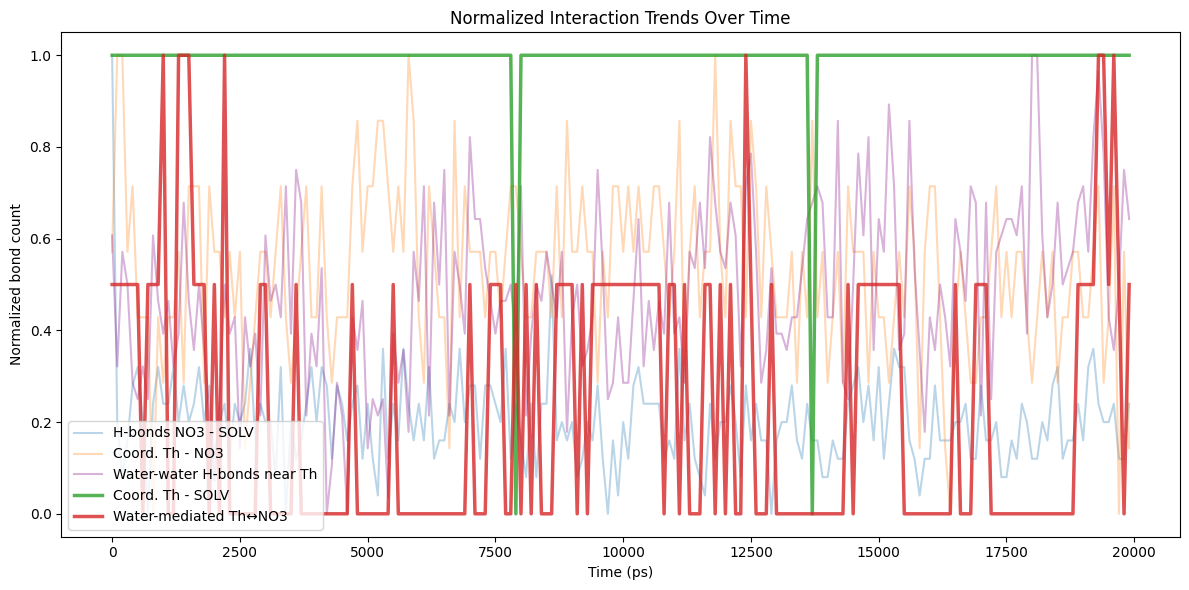

In [26]:
# --- Plotting all together ---
def normalize(arr):
    return (arr - np.min(arr)) / (np.max(arr) - np.min(arr))

plt.figure(figsize=(12, 6))
plt.plot(ghb.times, normalize(counts_hetb_solv), label=f"H-bonds {HETB} - SOLV", alpha=0.3)
plt.plot(times_coord, normalize(coord_counts_hetb), label=f"Coord. {HETA} - {HETB}", alpha=0.3)
plt.plot(ghb.times, normalize(water_water_near_heta), label=f"Water-water H-bonds near {HETA}", color="purple", alpha=0.3)
plt.plot(times_coord, normalize(coord_counts_solv), label=f"Coord. {HETA} - SOLV", linewidth=2.5, alpha=0.8)
plt.plot(times_coord, normalize(water_mediated_heta), label=f"Water-mediated {HETA}↔{HETB}", linewidth=2.5, alpha=0.8)
plt.xlabel("Time (ps)")
plt.ylabel("Normalized bond count")
plt.title("Normalized Interaction Trends Over Time")
plt.legend()
plt.tight_layout()
plt.show()
